# Question 1.4
Given the following for the planar quadrotor
$$
\begin{align}
& \frac{\ddot q_1(t)}{\ddot q_(t) + g} = -\tan(q_3(t))  
\end{align}
$$
(a) Given $q_3(0) = q_3(T) = 0$, then this implies that when $t \in \set{0,T}$
$$
\begin{align*}
\frac{\ddot q_1(t)}{\ddot q_(t) + g} &= 0, (\text{ as} \tan(t) = 0)\\
\implies \ddot q_1(t) &= 0, (\text{ as denominator cannot be zero})
\end{align*}
$$
Therefore $q_1(t)$ has **zero acceleration** at the initial and final locations


(b)  We first take the time derivative of eq. 1.20 from the text
$$
\begin{align*}
\frac{d}{dt}\Big(\frac{\ddot q_1(t)}{\ddot q_(t) + g} &= -\tan(q_3(t))\Big) \\
\frac{\dddot q_1(t)}{\ddot q_(t) + g} + \Big(\frac{-\ddot q_1(t)}{\ddot q_(t) + g}\Big)\cdot\frac{\dddot q_2(t)}{\ddot q_(t) + g} &= -\dot q_3(t)(1+\tan^2(q_3(t))) \\
\frac{\dddot q_1(t)}{\ddot q_(t) + g} + \Big(\tan(q_3(t))\Big)\cdot\frac{\dddot q_2(t)}{\ddot q_(t) + g} &= -\dot q_3(t)(1+\tan^2(q_3(t))) \\
\end{align*}
$$
Given $\dot q_3(0) = \dot q_3(T) = 0$, then this implies that when $t \in \set{0,T}$
$$
\begin{align*}
\frac{\dddot q_1(t)}{\ddot q_(t) + g} + 0\cdot\frac{\dddot q_2(t)}{\ddot q_(t) + g} &= 0 , (\text{ as} \tan(t) = 0)\\
\implies \dddot q_1(t) &= 0, (\text{ as denominator cannot be zero})
\end{align*}
$$
Therefore $q_1(t)$ has **zero jerk** at the initial and final locations

(c) To find the functions $q_1, q_2$ I assumed them to be an polynomial of degree 8. This can be written as $q(t) = \sum\limits_{n = 0}^8 a_nt^n$. Here I have dropped the subscript because the procedure is same for both the variables.
If we tabulate the derivatives along with their initial and final conditions:

| $q \in  \set{q_1, q_2}$                                     | $t = 0$ | $t = T$ |
| ----------------------------------------------------------- | ------- | ------- |
| $q(t) = \sum\limits_{n = 0}^7 a_nt^n$                       | 0       | 1       |
| $\dot q(t) = \sum\limits_{n = 1}^7 na_nt^{n-1}$             | 0       | 0       |
| $\ddot q(t) = \sum\limits_{n = 2}^7 n(n-1)a_nt^{n-2}$       | 0       | 0       |
| $\dddot q(t) = \sum\limits_{n = 3}^7 n(n-1)(n-2)a_nt^{n-3}$ | 0       | 0       |

If we define the following  $$
\begin{align}
\textbf a &= \begin{bmatrix}a_0 & a_1 &\cdots & a_7\end{bmatrix}^\top \text{ coefficient vector},\\ \textbf e &= \begin{bmatrix}q(0)& \dot q(0)& \ddot q(0)& \dddot q(0)& q(T)& \dot q(T)& \ddot q(T)& \dddot q(T)\end{bmatrix}^\top \text{ vector containing the initial and final conditions}\\
\textbf{Q} &= \begin{bmatrix}
\alpha(0)&\dot \alpha(0)&\ddot \alpha(0)&\dddot \alpha(0)&
\alpha(T)&\dot \alpha(T)&\ddot \alpha(T)&\dddot \alpha(T)
\end{bmatrix}^\top; \alpha(t) = [1, t, t^2 \cdots t^7]
\end{align}
$$
Then our problems can be expressed as a system of linear equations
$$
\textbf{Qa} = \textbf{e}
$$
which can then be solved to get the coefficients  

Solving this system for the values tabulated above yields the following polynomial:
$$
q_1(t) = q_2(t) = 2.19t^4-2.63t^5+1.09t^6-0.16t^7
$$


In [32]:
import numpy as np
import matplotlib.pyplot as plt

In [33]:
# Numerical parameters.
m = 1 # mass
g = 10 # gravity
r = .2 # length
I = .1 # moment of inertia
T = 2 # time horizon

In [34]:
# Helper funcion the computes derivative of order n.
def derivative(f, t, h=1e-4):
    return (f(t + h) - f(t)) / h
def derivative_order_n(f, t, n):
    if n == 1:
        return derivative(f, t)
    else:
        df = lambda t: derivative(f, t)
        return derivative_order_n(df, t, n - 1)

In [35]:
deg = 8
der = 8
C = np.zeros((der, deg))

d0q1 = lambda t: np.array([1 if n == 0 and t == 0 else t**n for n in range(deg)])
t = 0
C[0, :] = d0q1(t)
for i in range(3):
    C[i+1, :] = derivative_order_n(d0q1, t=t, n=i+1)

t=T
C[4, :] = d0q1(t)
for i in range(3):
    C[i+1+4, :] = derivative_order_n(d0q1, t=t, n=i+1)

q = np.array([0, 0, 0, 0, 1, 0, 0, 0]).T
coeff = np.linalg.inv(C)@q

    
# Center of mass trajectory
def q1(t):
    global coeff
    deg = len(coeff)
    return coeff @ np.array([1 if n == 0 and t == 0 else t**n for n in range(deg)])
def q2(t):
    global coeff
    deg = len(coeff)
    return coeff @ np.array([1 if n == 0 and t == 0 else t**n for n in range(deg)])

In [29]:
# Differential flatness.
def q3(t):
    ddq1 = derivative_order_n(q1, t, 2)
    ddq2 = derivative_order_n(q2, t, 2)
    return - np.arctan2(ddq1, ddq2 + g)
def u(t):
    ddq1 = derivative_order_n(q1, t, 2)
    ddq2 = derivative_order_n(q2, t, 2)
    ddq3 = derivative_order_n(q3, t, 2)
    a = m * np.sqrt(ddq1 ** 2 + (ddq2 + g) ** 2) / 2
    b = I * ddq3 / 2 / r
    return np.array([a - b, a + b])

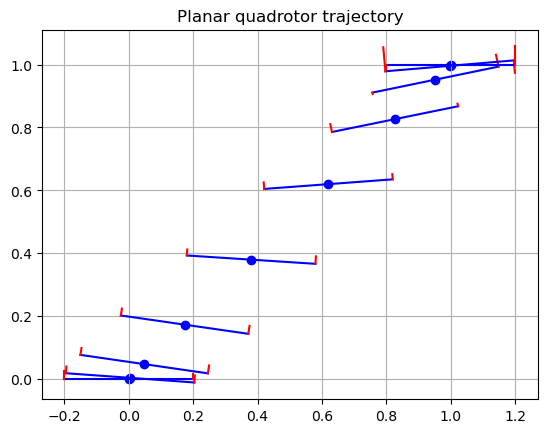

In [30]:
# Plot quadrotor snapshots.
plt.figure()
snapshots = 10
times = np.linspace(0, T, snapshots)
for t in times:
    q1t = q1(t)
    q2t = q2(t)
    q3t = q3(t)

    # Quadrotor body.
    c3t = np.cos(q3t)
    s3t = np.sin(q3t)
    endpoints = np.array([
        [q1t - r * c3t, q2t - r * s3t],
        [q1t + r * c3t, q2t + r * s3t]])
    plt.scatter(q1t, q2t, c='b')
    plt.plot(*endpoints.T, c='b')
    
    # Rotor thrusts as red segments.
    d = endpoints[1] - endpoints[0]
    v = np.array([-d[1], d[0]]) / 100
    for ui, ei in zip(u(t), endpoints):
        force = np.array([ei, ei + v * ui])
        plt.plot(*force.T, c='r')

# Plot options.
plt.title('Planar quadrotor trajectory')
plt.grid()

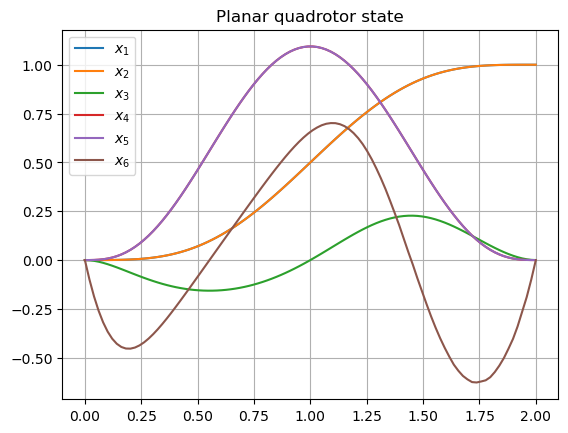

In [31]:
# Plot state trajectory.
sample_points = 100
times = np.linspace(0, T, sample_points)
x = np.zeros((sample_points, 6))
for i, t in enumerate(times):
    x[i, :3] = q1(t), q2(t), q3(t)
    x[i, 3:] = derivative(q1, t), derivative(q2, t), derivative(q3, t)
for i, xi in enumerate(x.T):
    plt.plot(times, xi, label=fr'$x_{i+1}$')

# Plot options.
plt.title('Planar quadrotor state')
plt.grid()
plt.legend()